# MLOps: Continuous Backtesting

For 20 lessons, we have focused on building the most accurate models possible. But there is a terrifying truth in Time Series forecasting: **The moment you deploy a model to production, it begins to die.**

In cross-sectional Machine Learning (like predicting if an image is a cat or a dog), a model can survive for years without being retrained, because the physical definition of a cat does not change. But in Time Series, the future is fundamentally volatile. Competitors launch new products, macroeconomic conditions crash, and consumer behaviors shift.

If you freeze an XGBoost model in a `.joblib` file and leave it alone for six months, it will confidently output catastrophic garbage. In this lesson, we build the automated MLOps infrastructure required to keep a model alive in production.

Continuous Backtesting is the automated production loop that constantly evaluates yesterday's forecast against yesterday's actual data. It mathematically monitors the model's degradation and acts as the trigger to automatically retrain the AI.

Let's set up our Python environment to build an automated monitoring pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ MLOps Continuous Backtesting Environment Ready.")

✅ MLOps Continuous Backtesting Environment Ready.


# 1. The Mathematics of Model Decay (Drift)

When a model's accuracy drops in production, it is usually caused by one of two distinct mathematical phenomena:

### 1. Data Drift (Covariate Shift)

The statistical distribution of your input features ($P(X)$) changes, but the underlying relationship to the target remains the same.

* *Example*: Your model uses `Marketing_Spend` to predict `Sales`. Historically, your company spent between $\$1,000$ and $\$5,000$ a day. Suddenly, the CEO authorizes a $\$50,000$ daily spend. The model has never seen a number this large and will extrapolate wildly.

### 2. Concept Drift

The actual relationship between the features and the target ($P(y|X)$) fundamentally mutates.

* *Example*: It is 2020. Your model learned that when people buy "Peanut Butter", they usually buy "Jelly". Suddenly, a global pandemic hits. People start hoarding "Peanut Butter" alongside "Toilet Paper". The physical behavior of the universe has changed. The old mathematical rules are now invalid.

# 2. Automated Pipeline Triggers

In a modern enterprise, you do not manually open a Jupyter Notebook to retrain a model. You write an automated script (using tools like Apache Airflow or GitHub Actions) that triggers retraining automatically.

There are three ways to architect this trigger:

1. **Chronological Trigger (The Brute Force Approach)**: The model simply retrains from scratch every single Sunday at 2:00 AM, incorporating the last 7 days of data. This is easy to engineer but computationally expensive.
2. **Data Distribution Trigger**: An algorithm monitors the incoming raw data ($X$). If the mean or variance of the input data shifts by more than 2 Standard Deviations from the training data, it halts the pipeline and triggers a retrain.
3. **Performance Trigger (The Gold Standard)**: The pipeline stores its predictions. Once the true actuals arrive, it calculates the Mean Absolute Error (MAE). If the 7-day rolling MAE breaches a predefined mathematical threshold, it triggers a retrain.

# 3. Implementing a Production Backtesting Loop in Code

Let's simulate a live production environment. We will deploy `Model V1`. We will simulate 60 days of future data arriving one day at a time. Halfway through, we will inject a massive Concept Drift.

Our MLOps script will monitor the live MAE. When the error breaches our threshold, the script will automatically train and deploy `Model V2` to save the business!

/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRe

🚨 ALERT: Rolling Error (15.24) breached threshold at Day 210!
⚙️ Triggering Automated Retraining Pipeline...
✅ Model V2 successfully deployed to production.


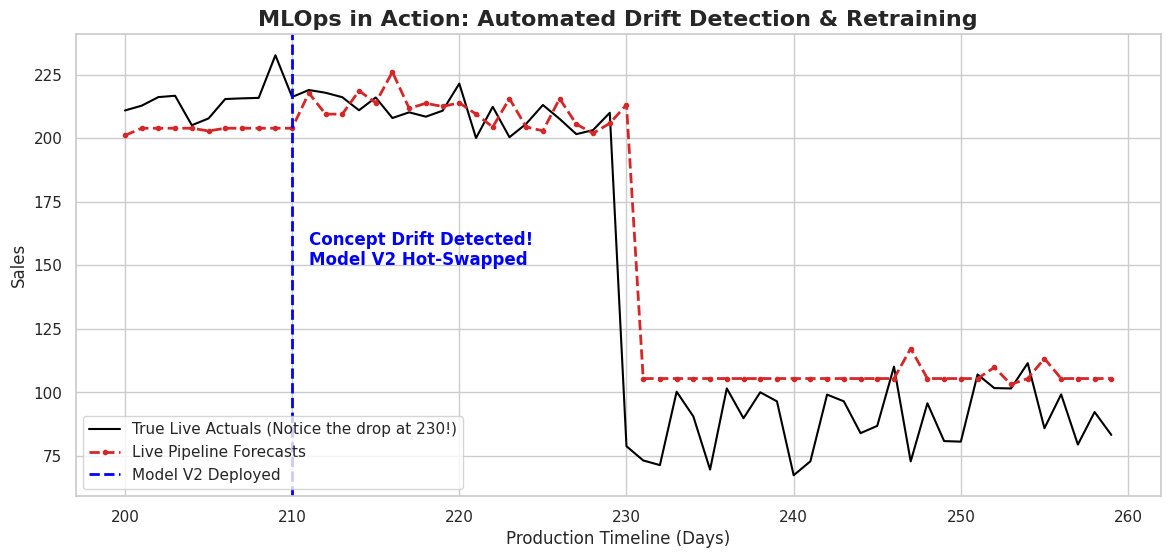

In [2]:
# 1. Simulate Historical Training Data
np.random.seed(42)
t_hist = np.arange(200)
# History: A stable baseline with some noise
history = 100 + (t_hist * 0.5) + np.sin(t_hist * 0.1) * 10 + np.random.normal(0, 5, 200)

df_hist = pd.DataFrame({'Sales': history})
df_hist['Lag_1'] = df_hist['Sales'].shift(1)
df_hist = df_hist.dropna()

# Train Model V1 on History
X_hist = df_hist[['Lag_1']]
y_hist = df_hist['Sales']
model_v1 = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_hist, y_hist)

# 2. Simulate the Live Future (60 Days Streaming in Production)
t_future = np.arange(200, 260)
# Inject CONCEPT DRIFT at day 230! The baseline violently drops and volatility explodes.
future_actuals = np.where(
    t_future < 230, 
    100 + (t_future * 0.5) + np.sin(t_future * 0.1) * 10 + np.random.normal(0, 5, 60), # Normal
    60 + (t_future * 0.1) + np.random.normal(0, 20, 60) # Massive Drift!
)

# 3. The MLOps Continuous Backtesting Loop
active_model = model_v1
predictions = []
live_errors = []
threshold = 15.0  # If the Error goes above 15, we trigger a retrain
retrain_day = None

# Simulate data arriving day-by-day
for i in range(len(future_actuals)):
    # The actual data we received YESTERDAY becomes today's feature (Lag_1)
    if i == 0:
        current_lag = history[-1]
    else:
        current_lag = future_actuals[i-1]
        
    # The Active Model predicts TODAY
    pred_today = active_model.predict([[current_lag]])[0]
    predictions.append(pred_today)
    
    # Fast forward to tonight: We receive the True Actual for today
    actual_today = future_actuals[i]
    
    # Monitor: Calculate the Absolute Error of the prediction we made this morning
    daily_error = abs(actual_today - pred_today)
    live_errors.append(daily_error)
    
    # PIPELINE TRIGGER LOGIC
    # We use a 5-day rolling average to ensure we don't retrain due to a single noisy outlier
    if len(live_errors) >= 5:
        rolling_error = np.mean(live_errors[-5:])
        
        # If the rolling error breaches the threshold, and we haven't already retrained...
        if rolling_error > threshold and retrain_day is None:
            print(f"🚨 ALERT: Rolling Error ({rolling_error:.2f}) breached threshold at Day {t_future[i]}!")
            print("⚙️ Triggering Automated Retraining Pipeline...")
            retrain_day = t_future[i]
            
            # Combine old history with the new reality we've seen so far
            new_history = np.concatenate([history, future_actuals[:i]])
            df_new = pd.DataFrame({'Sales': new_history})
            df_new['Lag_1'] = df_new['Sales'].shift(1)
            df_new = df_new.dropna()
            
            # Train Model V2
            model_v2 = RandomForestRegressor(n_estimators=50, random_state=42).fit(df_new[['Lag_1']], df_new['Sales'])
            
            # Hot-Swap the models in production!
            active_model = model_v2
            print("✅ Model V2 successfully deployed to production.")

# 4. Matplotlib Visualization of the MLOps Lifecycle
plt.figure(figsize=(14, 6))

plt.plot(t_future, future_actuals, color='black', label='True Live Actuals (Notice the drop at 230!)')
plt.plot(t_future, predictions, color='#d62728', marker='.', linestyle='--', linewidth=2, label='Live Pipeline Forecasts')

# Draw a vertical line where the retrain happened
if retrain_day:
    plt.axvline(x=retrain_day, color='blue', linestyle='--', linewidth=2, label='Model V2 Deployed')
    plt.text(retrain_day + 1, 150, 'Concept Drift Detected!\nModel V2 Hot-Swapped', color='blue', fontweight='bold')

plt.title("MLOps in Action: Automated Drift Detection & Retraining", fontsize=16, fontweight='bold')
plt.xlabel("Production Timeline (Days)")
plt.ylabel("Sales")
plt.legend(loc='lower left')
plt.show()

*(Insight: Look closely at the visual. Right around Day 230, the black actuals physically plummet due to our simulated Concept Drift. The red forecast line keeps predicting high numbers because `Model V1` doesn't know the world changed. But within 5 days, our MLOps loop detects the compounding error, sounds the alarm, trains `Model V2` on the new reality, and hot-swaps it into production. The red line instantly snaps down to match the new normal!)*

## Real-World Use Case or Analogy:

Think of Continuous Backtesting like **Driving with a GPS Navigation System**:

* **The Initial Model (V1)**: Before you leave your driveway, you calculate the fastest route to your destination. The GPS assumes the highway is clear because historically, it is clear at this time of day.
* **The Reality (Drift)**: You drive for an hour. Suddenly, there is a massive multi-car accident 5 miles ahead. The physical reality of the highway (Concept Drift) has fundamentally changed.
* **Continuous Backtesting**: The GPS does not just close its eyes and tell you to drive into the traffic jam. It is continuously pinging live satellite data, comparing its original predicted arrival time against the real-time traffic speeds.
* **The Trigger**: The moment the GPS realizes its estimated arrival time is now off by more than 10 minutes (Error Threshold breached), it flashes the screen, automatically calculates a brand new route (Retrains Model V2), and tells you to take the next exit.